# GrabCut Segmentation with Belief Propagation

This notebook runs BP segmentation on GrabCut-style image/mask pairs.

In [3]:
from pathlib import Path
import sys
import json

cwd = Path.cwd().resolve()
if (cwd / 'datasets').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'datasets').exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'PROJECT_ROOT = {PROJECT_ROOT}')


PROJECT_ROOT = /mnt/D/mva_P2/GRM/belief_propagation


In [4]:
# Run the full GrabCut experiment
grabcut_candidates = [
    PROJECT_ROOT / 'data' / 'grabcut',
    PROJECT_ROOT.parent / 'data' / 'grabcut',
]

def looks_like_grabcut(path: Path) -> bool:
    return (path / 'images').exists() and (path / 'masks').exists()

grabcut_path = next((p for p in grabcut_candidates if looks_like_grabcut(p)), None)
if grabcut_path is None:
    print('No GrabCut dataset found in common locations.')
    print('Checked:')
    for p in grabcut_candidates:
        print('  -', p)
    raise FileNotFoundError('Set `grabcut_path` manually to your GrabCut root (with images/ and masks/).')

results_dir = PROJECT_ROOT / 'results' / 'segmentation' / 'grabcut'
script_path = PROJECT_ROOT / 'experiments' / 'segmentation_grabcut.py'
print(f'Using GrabCut path: {grabcut_path}')
print(f'Writing results to: {results_dir}')
!python {script_path} --data-path {grabcut_path} --max-images 10 --resize 80 80 --results-dir {results_dir}


Using GrabCut path: /mnt/D/mva_P2/GRM/belief_propagation/data/grabcut
Writing results to: /mnt/D/mva_P2/GRM/belief_propagation/results/segmentation/grabcut
[1/1] IoU=0.0000 Acc=0.4741 Runtime=18.75s Iter=30 Converged=False

GrabCut experiment summary
Images: 1
Mean IoU: 0.0000
Mean accuracy: 0.4741
Mean runtime (s): 18.754
Mean iterations: 30.00
Convergence rate: 0.000


In [5]:
search_roots = []
if 'results_dir' in globals():
    search_roots.append(Path(results_dir))
search_roots.extend([
    PROJECT_ROOT / 'results' / 'segmentation',
    Path.cwd() / 'results' / 'segmentation',
    PROJECT_ROOT / 'notebooks' / 'results' / 'segmentation',
])

summary_path = None
for root in search_roots:
    candidate = root / 'grabcut' / 'summary.json'
    if candidate.exists():
        summary_path = candidate
        break

if summary_path is None:
    all_summaries = []
    for root in search_roots:
        if root.exists():
            all_summaries.extend(root.rglob('summary.json'))
    all_summaries = sorted(set(all_summaries), key=lambda p: p.stat().st_mtime, reverse=True)
    if not all_summaries:
        raise FileNotFoundError('No GrabCut summary.json found under known results directories.')
    summary_path = all_summaries[0]

print(f'Using summary: {summary_path}')
with summary_path.open() as f:
    summary = json.load(f)
summary


Using summary: /mnt/D/mva_P2/GRM/belief_propagation/results/segmentation/grabcut/summary.json


{'num_images': 1,
 'mean_iou': 0.0,
 'mean_accuracy': 0.4740625,
 'mean_runtime_sec': 18.753888538005413,
 'mean_iterations': 30.0,
 'convergence_rate': 0.0,
 'config': {'data_path': '/mnt/D/mva_P2/GRM/belief_propagation/data/grabcut',
  'max_images': 10,
  'resize': [80, 80],
  'max_iters': 30,
  'tol': 0.0001,
  'smoothness': 2.0,
  'seed': 0}}

Text(0.5, 1.0, 'sample_000_comparison.png')

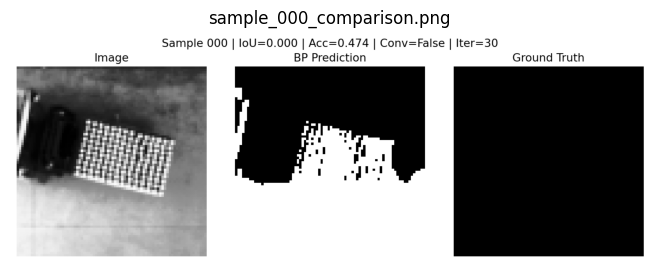

In [6]:
import matplotlib.pyplot as plt
from skimage import io

if summary_path is None:
    raise RuntimeError('Run previous cell first to set summary_path')
plot_dir = summary_path.parent / 'plots'
plot_files = sorted(plot_dir.glob('sample_*_comparison.png'))
if not plot_files:
    raise FileNotFoundError(f'No comparison plots found in {plot_dir}')
first_plot = plot_files[0]
plt.figure(figsize=(10, 3))
plt.imshow(io.imread(first_plot))
plt.axis('off')
plt.title(first_plot.name)
